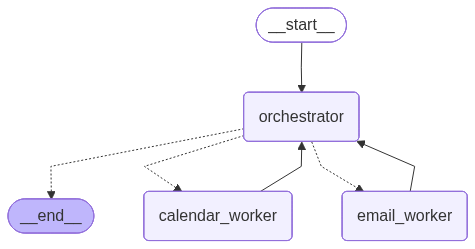

In [11]:
# backend / graph_logic/flow.py
from typing import Any, Dict, List, Union, Optional, Annotated
import os
import json
import asyncio
from operator import add
from datetime import datetime, timezone
import logging
import sys
import base64
from IPython.display import display, Image
import sys
import os

notebook_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if notebook_root not in sys.path:
    sys.path.append(notebook_root)


from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage

# For now we will use Sqlite for prototyping yah
# I will build the sqlite checkpointer here synchronousely here from prototyping
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from logic.graph.state import AgentState, saver
from logic.agents.calander_agent import calendar_worker_node
from logic.agents.ochestrator import orchestrator_node, orchestrator_router
from logic.agents.email_agent import email_worker_node
from langgraph.types import Command

graph_builder = StateGraph(AgentState)  # type: ignore

# Add nodes
graph_builder.add_node("orchestrator", orchestrator_node)
graph_builder.add_node("calendar_worker", calendar_worker_node)
graph_builder.add_node("email_worker",email_worker_node)

# Entry point: always start at the orchestrator
graph_builder.set_entry_point("orchestrator")

# Conditional edges: orchestrator decides where to go
graph_builder.add_conditional_edges(
    "orchestrator",
    orchestrator_router,
    {
        "calendar_worker": "calendar_worker",
        "email_worker": "email_worker",
        "__end__": END,
    }
)

# After the calendar worker finishes, always route back to the orchestrator
# The orchestrator will see the AI response and route to END
graph_builder.add_edge("calendar_worker", "orchestrator")
graph_builder.add_edge("email_worker", "orchestrator")

graph = graph_builder.compile(checkpointer=saver)





try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)
    pass


In [5]:
import sys
import os

# Print current working directory to understand location
print("CWD:", os.getcwd())

# Manually go up to your project root (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # try one level first

print("Project root guess:", project_root)

if project_root not in sys.path:
    sys.path.insert(0, project_root)


CWD: c:\Users\leeju\Projects\SC4052_Cloud_Project\backend\logic\graph
Project root guess: c:\Users\leeju\Projects\SC4052_Cloud_Project\backend\logic
